# Train RT-DETR on the ROD-Dataset
Real-Time Obstacle Detection — 25 classes, ~24,326 images. Dataset: https://www.kaggle.com/datasets/abtinzandi/obstacle-detection-dataset

# 1. Locate the dataset and write a frest `data.yaml`

In [22]:
import yaml
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")
src = next((p for p in INPUT_ROOT.rglob("data.yaml")), None)
assert src is not None, "data.yaml not found under /kaggle/input — did you Add the dataset?"
data_root = src.parent
print("Dataset root:", data_root)

with open(src) as f:
    orig = yaml.safe_load(f)

data_yaml = {
    "path":  str(data_root),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    orig["nc"],
    "names": orig["names"],
}
DATA = "/kaggle/working/data.yaml"
with open(DATA, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("Wrote", DATA, "|", data_yaml["nc"], "classes")
print(data_yaml["names"])

Dataset root: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset
Wrote /kaggle/working/data.yaml | 25 classes
['Bike', 'Building', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Dog', 'Manhole', 'Tree', 'Guard rail', 'Pedestrian crosswalk', 'Truck', 'Bus', 'Bench', 'Traffic Cone', 'Fire hydrant', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']


# 2. Install & environment check

In [1]:
!pip install -q ultralytics

In [2]:
from ultralytics import RTDETR
import torch

In [3]:
print(f"PyTorch: {torch.__version__}")
print(f"GPUs available: {torch.cuda.device_count()}")

PyTorch: 2.10.0+cu128
GPUs available: 2


# 3. Config

In [7]:
MODEL_VARIANT  = "rtdetr-l"          # options: rtdetr-l, rtdetr-x
WEIGHTS        = "rtdetr-l.pt"       # pretrained COCO checkpoint
EPOCHS         = 100
BATCH          = 16                 # RT-DETR is memory-heavy, start at 8
IMGSZ          = 512
DEVICE         = "0,1"              
EVAL_DEVICE    = 0
PATIENCE       = 20
COS_LR         = True
SEED           = 42
CONF           = 0.25
IOU            = 0.7
DATA_YAML      = "/kaggle/working/data.yaml"
PROJECT        = "/kaggle/working/runs"
RUN_NAME       = f"rod_{MODEL_VARIANT}"

In [8]:
print(f"Training {MODEL_VARIANT} | {EPOCHS} epochs | batch {BATCH} | imgsz {IMGSZ}")

Training rtdetr-l | 100 epochs | batch 16 | imgsz 512


In [9]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"GPU 0 free: {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB")
print(f"GPU 1 free: {torch.cuda.mem_get_info(1)[0]/1e9:.2f} GB")

GPU 0 free: 15.53 GB
GPU 1 free: 15.53 GB


# 4. Train

In [10]:
# Load pretrained model
model = RTDETR(WEIGHTS)

# Train
results = model.train(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    batch     = BATCH,
    imgsz     = IMGSZ,
    device    = DEVICE,
    patience  = PATIENCE,
    cos_lr    = COS_LR,
    seed      = SEED,
    project   = PROJECT,
    name      = RUN_NAME,
    exist_ok  = True,
    verbose   = True,
)

print("Training complete!")
print(results)


Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rod_rtdetr-l, nbs=64, nm

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution

      1/100      13.7G      0.475      1.377     0.2954          4       1024: 100% ━━━━━━━━━━━━ 1200/1200 1.5s/it 30:341.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 3.8it/s 28.8s0.2s
                   all       3511       5572      0.747       0.77      0.802       0.61

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution

      2/100      13.9G     0.4085     0.4592     0.2043          8       1024: 100% ━━━━━━━━━━━━ 1200/1200 1.4s/it 27:261.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 4.2it/s 26.5s0.2s
                   all       3511       5572      0.831      0.816      0.854      0.627

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution

     21/100      13.9G     0.4482     0.4087     0.1844          6       1024: 100% ━━━━━━━━━━━━ 1200/1200 1.3s/it 25:261.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 4.2it/s 25.9s0.2s
                   all       3511       5572       0.86      0.834      0.873      0.493

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 4.2it/s 25.9s0.2s
                   all       3511       5572      0.878      0.852      0.875      0.473
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 2, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

22 epochs completed in 9.655 hours.
Optimizer stripped from /kaggle/working/runs/rod_rtdetr-l/weights/last.pt, 66.3MB
Optimizer stripped from /kaggle/working/runs/rod_rtdetr-l/weights/best.pt, 66.3MB

Validating /kaggle/working/runs/rod_rtdetr-l/weights/best.pt...
rt-detr-l summary: 310 layers, 32,035,115 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 4.7it/s 23.2s0.2s
                   a

NameError: name 'Path' is not defined

In [12]:
from pathlib import Path

# Multi-GPU DDP training in a notebook relaunches as a subprocess and returns
# None in the parent process, so `results` may be None even though training
# finished. Fall back to locating the run directory under PROJECT/RUN_NAME.
if results is not None and getattr(results, "save_dir", None):
    RUN_DIR = Path(results.save_dir)
else:
    candidates = sorted(Path(PROJECT).glob(RUN_NAME + "*"),
                        key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise RuntimeError(f"No run directory found under {PROJECT}/{RUN_NAME}*")
    RUN_DIR = candidates[-1]
print("Run dir:", RUN_DIR)

Run dir: /kaggle/working/runs/rod_rtdetr-l


# 5. Validate on the held-out test split

In [16]:
import json

# Load best weights
best_weights = f"{PROJECT}/{RUN_NAME}/weights/best.pt"
eval_model = RTDETR(best_weights)

# Validate on val set
val_results = eval_model.val(
    data    = DATA_YAML,
    imgsz   = IMGSZ,
    device  = EVAL_DEVICE,
    conf    = CONF,
    iou     = IOU,
    split   = "val",
)

# Evaluate on test set
test_results = eval_model.val(
    data    = DATA_YAML,
    imgsz   = IMGSZ,
    device  = EVAL_DEVICE,
    conf    = CONF,
    iou     = IOU,
    split   = "test",
)

# Save summary
summary = {
    "model":         MODEL_VARIANT,
    "weights":       best_weights,
    "epochs":        EPOCHS,
    "imgsz":         IMGSZ,
    "batch":         BATCH,
    "mAP50_95":      float(test_results.box.map),
    "mAP50":         float(test_results.box.map50),
    "precision":     float(test_results.box.mp),
    "recall":        float(test_results.box.mr),
}

with open(f"{PROJECT}/{RUN_NAME}/eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
rt-detr-l summary: 310 layers, 32,035,115 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 108.5±30.9 MB/s, size: 64.4 KB)
val: Scanning /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/valid/labels... 3511 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3511/3511 763.1it/s 4.6s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/valid is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 821, len(boxes) = 5572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 2.3it/s 1:380.4

In [23]:
import time, glob

def benchmark(m, image_paths, imgsz, device=0, conf=0.25, iou=0.7, batch=8, warmup=5):
    for p in image_paths[:warmup]:
        _ = m.predict(p, imgsz=imgsz, device=device, conf=conf, iou=iou, verbose=False)
    t0 = time.perf_counter(); n = 0
    for i in range(0, len(image_paths), batch):
        chunk = image_paths[i:i + batch]
        _ = m.predict(chunk, imgsz=imgsz, device=device, conf=conf, iou=iou, verbose=False)
        n += len(chunk)
    dt = time.perf_counter() - t0
    return (dt / n) * 1000.0, n / dt, dt

test_imgs = sorted(glob.glob(str(data_root / "test/images/*.jpg")))
avg_ms, fps, total_s = benchmark(eval_model, test_imgs, IMGSZ, device=EVAL_DEVICE,
                                 conf=CONF, iou=IOU, batch=BATCH)
print(f"{avg_ms:.2f} ms/img | {fps:.1f} FPS | {total_s:.1f}s over {len(test_imgs)} images")

42.79 ms/img | 23.4 FPS | 69.7s over 1629 images


In [24]:
import json
from datetime import datetime

rd = metrics.results_dict
summary = {
    "model":          MODEL_VARIANT,
    "weights":        str(best),
    "timestamp":      datetime.now().isoformat(timespec="seconds"),
    "epochs":         EPOCHS,
    "imgsz":          IMGSZ,
    "batch":          BATCH,
    "params":         int(sum(p.numel() for p in eval_model.model.parameters())),
    "mAP50_95":       rd.get("metrics/mAP50-95(B)"),
    "mAP50":          rd.get("metrics/mAP50(B)"),
    "precision":      rd.get("metrics/precision(B)"),
    "recall":         rd.get("metrics/recall(B)"),
    "avg_ms_per_img": round(avg_ms, 3),
    "fps":            round(fps, 2),
    "test_images":    len(test_imgs),
}
out_json = Path("/kaggle/working") / f"{MODEL_VARIANT}_summary.json"
out_json.write_text(json.dumps(summary, indent=2))
out_txt = Path("/kaggle/working") / f"{MODEL_VARIANT}_results.txt"
out_txt.write_text("\n".join(f"{k}: {v}" for k, v in summary.items()))
print(json.dumps(summary, indent=2))

{
  "model": "rtdetr-l",
  "weights": "/kaggle/working/runs/rod_rtdetr-l/weights/best.pt",
  "timestamp": "2026-06-23T01:24:48",
  "epochs": 100,
  "imgsz": 512,
  "batch": 16,
  "params": 32035115,
  "mAP50_95": 0.6203320571618408,
  "mAP50": 0.854167731030697,
  "precision": 0.8337795952770949,
  "recall": 0.8258357629345681,
  "avg_ms_per_img": 42.791,
  "fps": 23.37,
  "test_images": 1629
}


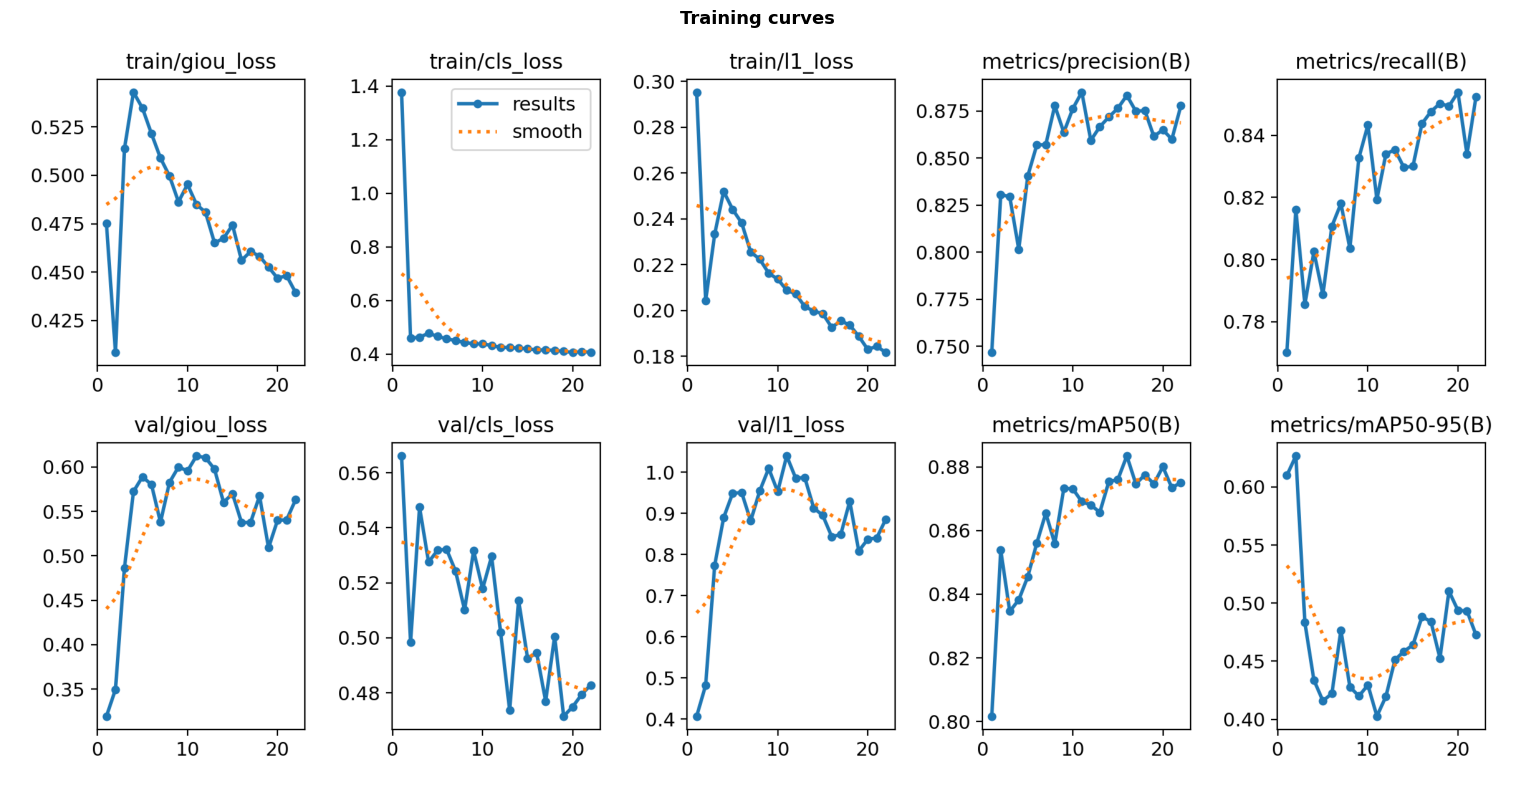

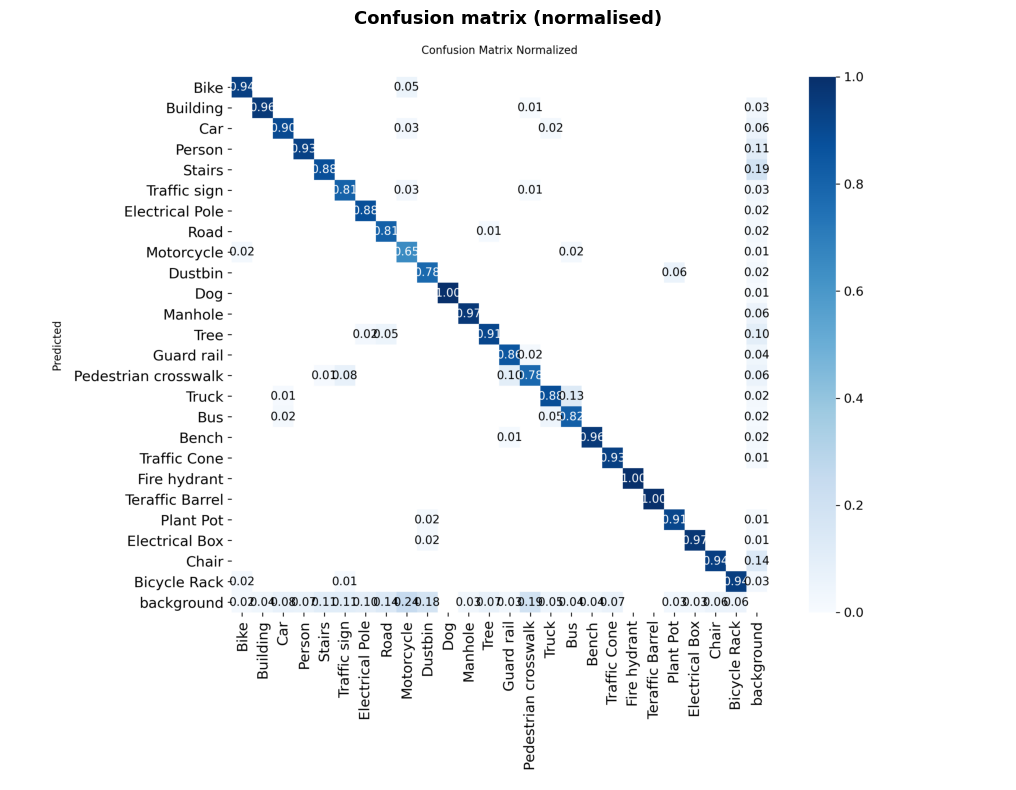

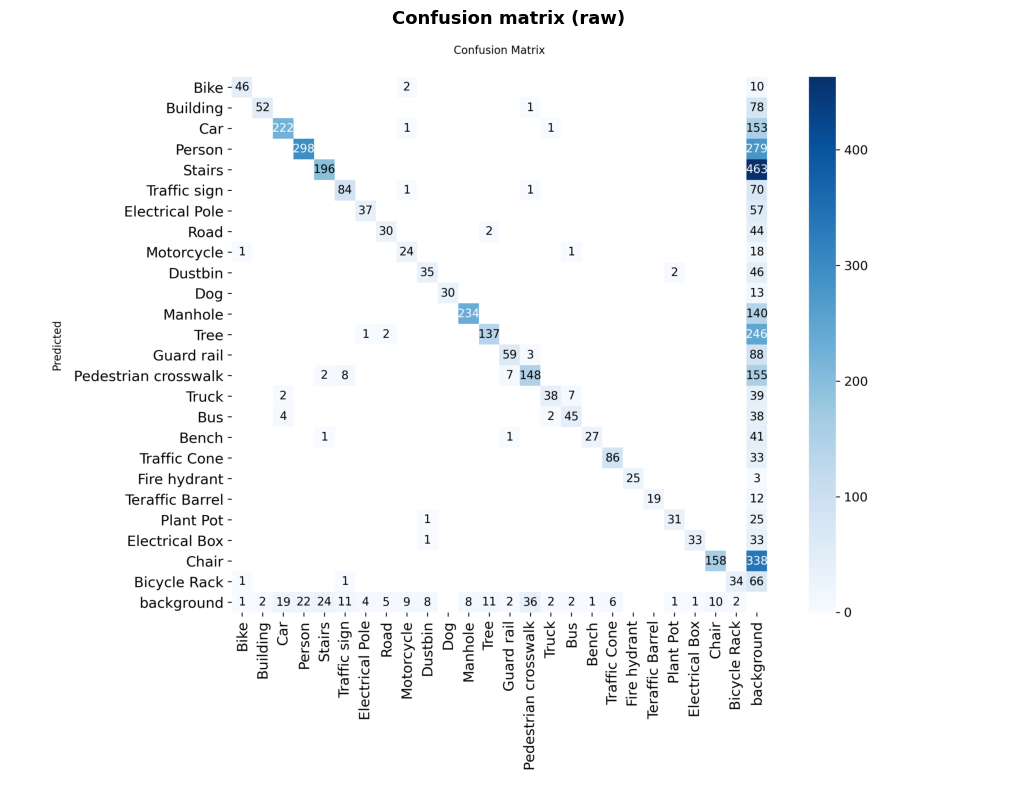

[skip] PR_curve.png not found
[skip] F1_curve.png not found
[skip] P_curve.png not found
[skip] R_curve.png not found


In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show(path, title=""):
    path = Path(path)
    if not path.exists():
        print("[skip]", path.name, "not found"); return
    plt.figure(figsize=(16, 8))
    plt.imshow(mpimg.imread(str(path)))
    plt.axis("off")
    if title:
        plt.title(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

show(RUN_DIR / "results.png",                     "Training curves")
show(VAL_DIR / "confusion_matrix_normalized.png", "Confusion matrix (normalised)")
show(VAL_DIR / "confusion_matrix.png",            "Confusion matrix (raw)")
show(VAL_DIR / "PR_curve.png",                    "Precision-Recall curve")
show(VAL_DIR / "F1_curve.png",                    "F1-Confidence curve")
show(VAL_DIR / "P_curve.png",                     "Precision-Confidence curve")
show(VAL_DIR / "R_curve.png",                     "Recall-Confidence curve")

Results saved to /kaggle/working/runs/predict


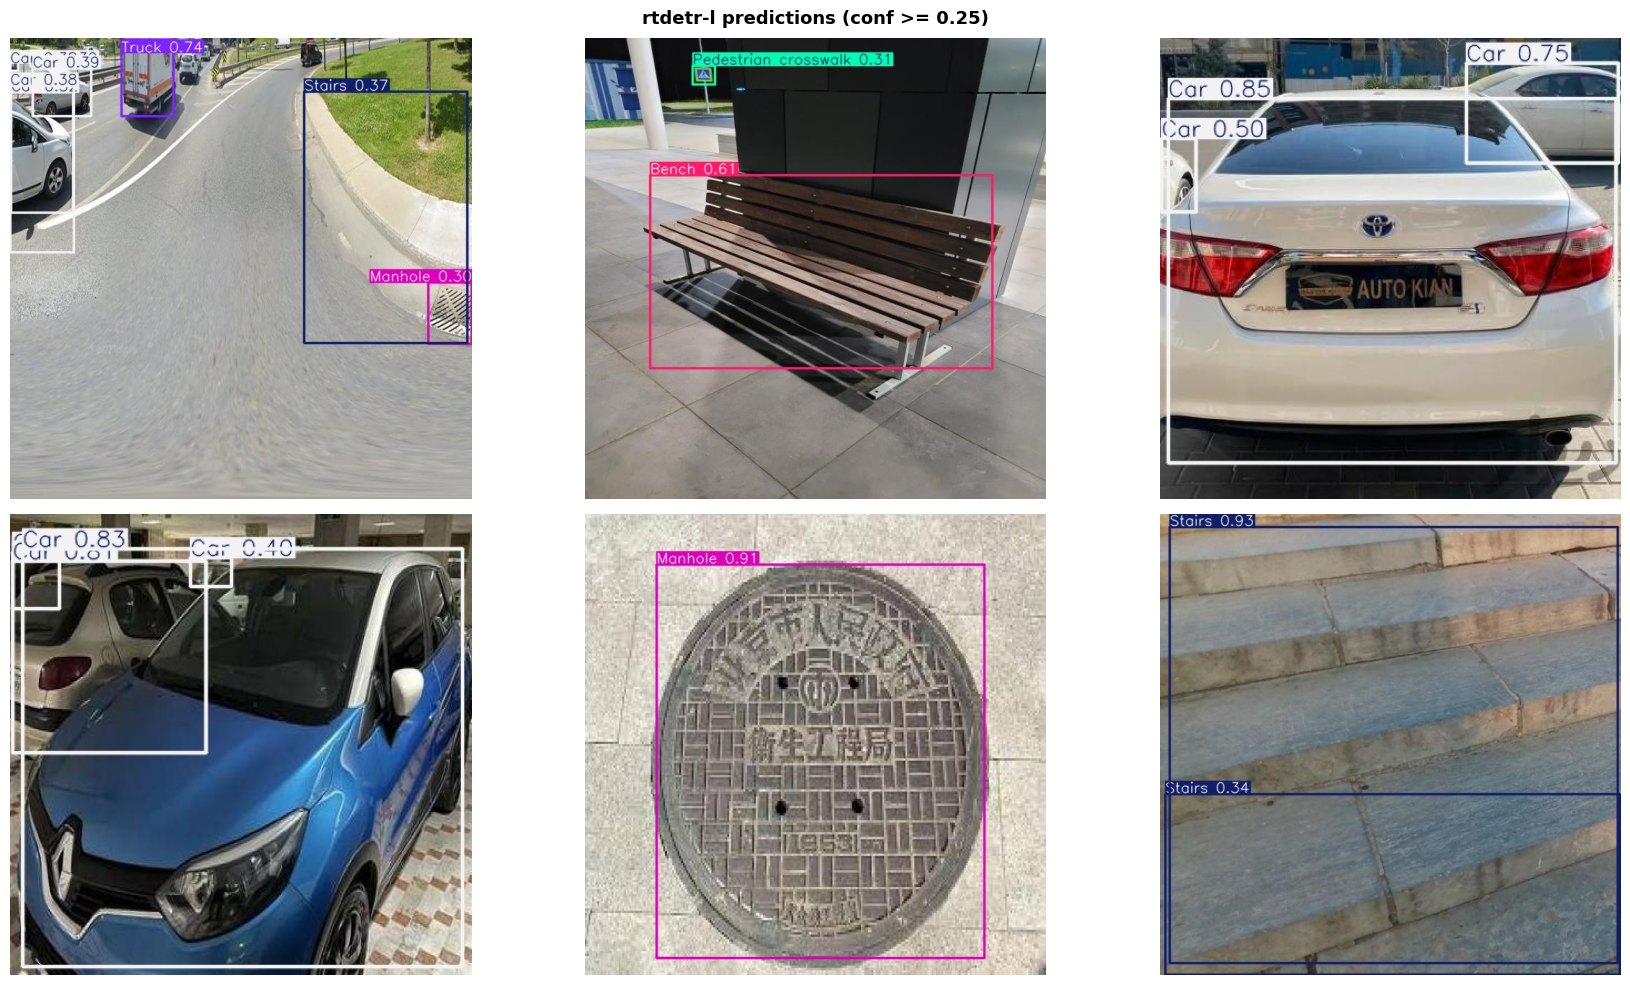

In [26]:
import random
random.seed(SEED)
samples = random.sample(test_imgs, min(6, len(test_imgs)))

eval_model.predict(samples, imgsz=IMGSZ, conf=CONF, device=EVAL_DEVICE, save=True,
                   project=PROJECT, name="predict", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
pred_imgs = sorted(glob.glob(f"{PROJECT}/predict/*.jpg"))[:6]
for ax, p in zip(axes.flat, pred_imgs):
    ax.imshow(mpimg.imread(p)); ax.axis("off")
for ax in axes.flat[len(pred_imgs):]:
    ax.axis("off")
plt.suptitle(f"{MODEL_VARIANT} predictions (conf >= {CONF})", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [27]:
import shutil
for w in (RUN_DIR / "weights" / "best.pt", RUN_DIR / "weights" / "last.pt"):
    if w.exists():
        dst = Path("/kaggle/working") / f"{MODEL_VARIANT}_{w.name}"
        shutil.copy(str(w), str(dst))
        print("Saved", dst)

Saved /kaggle/working/rtdetr-l_best.pt
Saved /kaggle/working/rtdetr-l_last.pt
